In [310]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Basic Functions for operating the Filter
# ==========================================

# =======================================
# Dynamic Model of the System
# =======================================

# In this function we define how the hidden Markov Chain evolves

def Dynamic_Model_Equations(vector,N):

    # Observe that in this scenario we consider Uniform Noise
    u = Dynamic_System_Noise(vector.shape)

    return NonLinear_Function_f(vector) + u

# Non Linear Function that control the evolution of the system
def NonLinear_Function_f(vector):
    if vector.ndim == 1:
        xn, yn = vector[0], vector[1]
    else:
        xn, yn = vector[0, :], vector[1, :]
   
    # Insert here the non linear function f
    x_n_new = 3 * np.tanh(yn) + xn + np.sin(yn) 
    y_n_new = 0.5 * np.tanh(xn) + yn + np.sin(yn)
    
    return np.array([x_n_new,
                     y_n_new])

def Dynamic_System_Noise(shape):
    # Here we adopted the uniform noise
    low =  -1
    high = -low
    return np.random.uniform(low,high,shape)

# =======================================
# Observation Model of the System
# =======================================

# In this function we define how the hidden Markov Chain are
# related with the observable measurements

def Observation_Model(vector,N):

    # We have 1 equation that control de Observation Model
    # Observe that in this scenario we consider a Cauchy noise
    v = Observation_Model_Noise(N)

    return NonLinear_Function_g(vector) + v

# Non Linear Function that control the Observation Model
def NonLinear_Function_g(vector):
    if vector.ndim == 1:
        xn, yn = vector[0], vector[1]
    else:
        xn, yn = vector[0, :], vector[1, :]

    # 1 observation equation
    o_n = 1/xn + yn**2
    
    return o_n
    
def Observation_Model_Noise(M):
    # Here we adopted a Cauchy noise
    gamma = 1/50
    return gamma*np.random.standard_cauchy(M)
    
def PDF_Weight_Calculator(x):
    # In this function we will compute the PDF for evaluating the weights
    # of the Particle Filter
    gamma = 1/50
    return (1/(np.pi*gamma))*(1 + (x/gamma)**2)**(-1)

# =======================================
# Generation of the Trajectory
# =======================================

# In this function we are going to generate the trajectory and the observable measurements
def Generation_Trajectory(Nsteps,Ndim_system,Ndim_obs):

    # Two structures to store the generated data
    Data_Markov_Chain = np.zeros((Ndim_system,Nsteps))
    Data_Measurements = np.zeros((Ndim_obs,Nsteps))

    # First state of the Markov Chain
    Data_Markov_Chain[:,0] = Dynamic_System_Noise((Ndim_system,))

    # First Measurement
    Data_Measurements[:,0] = Observation_Model(Data_Markov_Chain[:,0],Ndim_obs)

    # For the states n >= 1
    for i in range(1,Nsteps):
        Data_Markov_Chain[:,i] = Dynamic_Model_Equations(Data_Markov_Chain[:,i - 1],Ndim_system)
        Data_Measurements[:,i] = Observation_Model(Data_Markov_Chain[:,i],Ndim_obs)

    return Data_Markov_Chain, Data_Measurements

# =======================================
# Generation of J Particles
# =======================================

def Particle_Generator(J, Ndim_system, M_Particles_prev):
    
    Data_Particle = np.zeros((Ndim_system, J))
    for j in range(J):
        # Each particle depend on the previous state
        Data_Particle[:, j] = Dynamic_Model_Equations(M_Particles_prev[:, j], Ndim_system)
    return Data_Particle


def Weighted_Average(Ndim_sys,vector_weights,Particles,J):
    v_sum = np.zeros(Ndim_sys)
    for m in range(J):
        v_sum = v_sum + vector_weights[m]*Particles[:,m]

    return v_sum

def Effective_number_Particles(vector_weights):
    # Health metric of the Filter - detects degeneracy
    return (np.sum(vector_weights**2))**(-1)

# =======================================
# Plots
# =======================================

def Plot_Est_x_Real(Real_States, Estimated_States, Nsteps):
    # Initialize a single consolidated layout for State-Space (X vs Y)
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Plotting True State Trajectory: x1 on Horizontal Axis, y2 on Vertical Axis
    ax.plot(Real_States[0, :], Real_States[1, :], 
            label='True State Trajectory ($x_1$ vs $y_2$)', 
            color='black', lw=1.5, alpha=0.8, marker='o', markersize=3)
    
    # Plotting Filter Estimated Trajectory
    ax.plot(Estimated_States[0, :], Estimated_States[1, :], 
            label='PF Estimated Trajectory ($\hat{x}_1$ vs $\hat{y}_2$)', 
            color='crimson', linestyle='--', lw=1.5, marker='x', markersize=4)
    
    # Mark the start of the trajectories to give context
    ax.scatter(Real_States[0, 0], Real_States[1, 0], color='blue', zorder=5, label='Initial State ($n=0$)')
    ax.scatter(Real_States[0, -1], Real_States[1, -1], color='green', zorder=5, label='Final State ($n=N$)')

    # Formatting and Styling properties
    ax.set_title('Particle Filter Tracking Performance - State Space ($x$ vs $y$)', fontsize=14, fontweight='bold')
    ax.set_xlabel('State $x_1$ Magnitude', fontsize=12)
    ax.set_ylabel('State $y_2$ Magnitude', fontsize=12)
    margin_x = (Real_States[0, :].max() - Real_States[0, :].min()) * 0.2
    margin_y = (Real_States[1, :].max() - Real_States[1, :].min()) * 0.2
    ax.set_xlim(Real_States[0, :].min() - margin_x, Real_States[0, :].max() + margin_x)
    ax.set_ylim(Real_States[1, :].min() - margin_y, Real_States[1, :].max() + margin_y)
    
    # Configuration of the legend layout
    ax.legend(loc='best', frameon=True, shadow=True)
    ax.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# =======================================
# Particle Filter - Main Algorithm
# =======================================

def Particle_Filter(N_steps,Ndim_system,J,M_observations):

    # Store the weigths of the Particle
    Matrix_weights_Particle = np.zeros((J,N_steps))

    # Store the set of the Particle
    M_Particles = np.zeros((N_steps,Ndim_system,J))

    # Estimated Hidden States 
    Hidden_State_Est = np.zeros((Ndim_system,N_steps))

    # ===========================
    # Inicialization of the Filter
    # ===========================

    # Particles (n = 0) --> Blind Proposal Function
    M_Particles[0,:,:] = Dynamic_System_Noise((Ndim_system, J))

    # Weights (n = 0)
    for k in range(J):
        Matrix_weights_Particle[k,0] = \
        PDF_Weight_Calculator(M_observations[:,0].item() - NonLinear_Function_g(M_Particles[0,:,k]))

    # Normalize
    Matrix_weights_Particle[:,0] = Matrix_weights_Particle[:,0] /np.sum(Matrix_weights_Particle[:,0])
    
    # Calculating the first estimate of the Hidden state
    Hidden_State_Est[:,0] = Weighted_Average(Ndim_system,
                                             Matrix_weights_Particle[:,0],
                                             M_Particles[0,:,:],
                                             J)
    for step in range(1,N_steps):

        # =====================
        # Particle Generation
        # Sampling Step
        # =====================

        M_Particles[step, :, :] = Particle_Generator(J,
                                                     Ndim_system,
                                                     M_Particles[step - 1, :, :])
        
        # =====================
        # Weights Update
        # =====================

        previous_weights = Matrix_weights_Particle[:, step - 1].copy()

        for particle in range(J):
             Matrix_weights_Particle[particle,step] = previous_weights[particle] *\
                PDF_Weight_Calculator(M_observations[:,step].item() - NonLinear_Function_g(M_Particles[step,:,particle]))

        # Normalize
        sum_w = np.sum(Matrix_weights_Particle[:,step])
        if sum_w == 0:
            Matrix_weights_Particle[:,step] = np.ones(J) / J
        else:
            Matrix_weights_Particle[:,step] = Matrix_weights_Particle[:,step]/sum_w
       
        # =====================
        # Health of the Filter
        # =====================

        Neff = Effective_number_Particles(Matrix_weights_Particle[:,step])

        # =====================
        # Resampling step
        # =====================

        # We use a threshold of 70% to trigger resampling
        if Neff < 0.7 * J:
            # 1.Multinomial resampling based on the normalized weights
            sampled_index = np.random.choice(np.arange(J), size=J, p=Matrix_weights_Particle[:, step])
            
            # 2. Copy of the particles
            M_Particles[step, :, :] = M_Particles[step, :, :][:, sampled_index]
            
            # 3. New weights
            Matrix_weights_Particle[:, step] = np.ones(J) / J


        # =====================
        # Estimation
        # =====================
        Hidden_State_Est[:,step] = Weighted_Average(Ndim_system,
                                                    Matrix_weights_Particle[:,step],
                                                    M_Particles[step,:,:],
                                                    J)
    return Hidden_State_Est

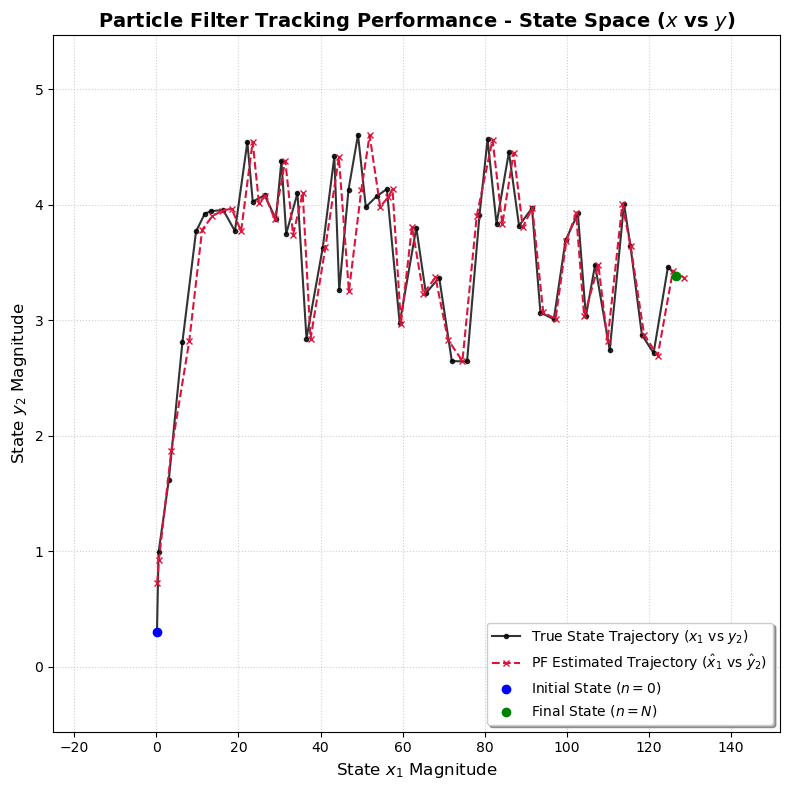

In [311]:
# =======================================
# Simulation Setup Execution
# =======================================

# General parameters configuration
N_orbit = 50
Ndim_system = 2
Ndim_obs = 1
J = 1000 # Number of particle hypotheses

# 1. Simulate the benchmark true trajectory
Real_Trajectory, Observations = Generation_Trajectory(N_orbit, Ndim_system, Ndim_obs)

# 2. Run the tracking Filter
Estimated_Trajectory = Particle_Filter(N_orbit, Ndim_system, J, Observations)

# 3. Call the visualization: State Space, x versus y
Plot_Est_x_Real(Real_Trajectory, Estimated_Trajectory, N_orbit)